<a href="https://colab.research.google.com/github/VishalRaut-vr/ML-Practice-Code/blob/main/customer_segmentation_kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("krishnaraj30/mall-visiting-customer-data")

print("Path to dataset files:", path)

100%|██████████| 1.55k/1.55k [00:00<00:00, 1.93MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/krishnaraj30/mall-visiting-customer-data/versions/1


In [ ]:
import os
print(os.listdir(path))
df = pd.read_csv(os.path.join(path, "Mall_Customers.csv"))
df.head()

['Mall_Customers.csv']


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# 1.Basic EDA

In [ ]:
print(df.shape)

(200, 5)


In [ ]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [ ]:
df['Annual Income (k$)'] = df['Annual Income (k$)'].fillna(df['Annual Income (k$)'].median())

## Data cleaning

In [ ]:
# Convert Gender to numeric
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
print("DataFrame after Gender conversion:")
display(df.head())

DataFrame after Gender conversion:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


## Univariate Analysis (Single Column)

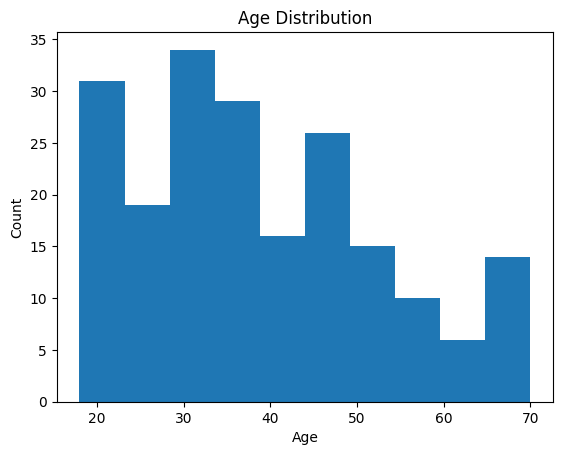

In [ ]:
#Age Distribution
plt.hist(df['Age'])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

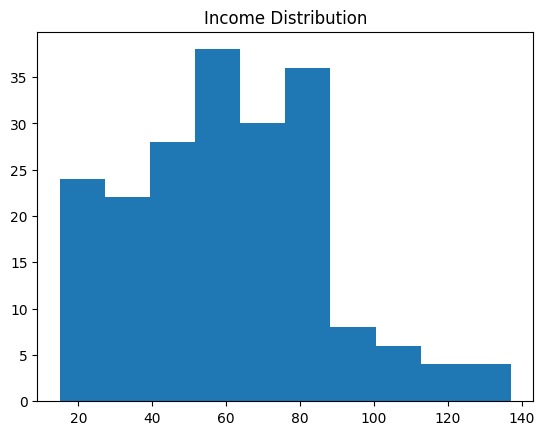

In [ ]:
# Income Distribution
plt.hist(df['Annual Income (k$)'])
plt.title("Income Distribution")
plt.show()

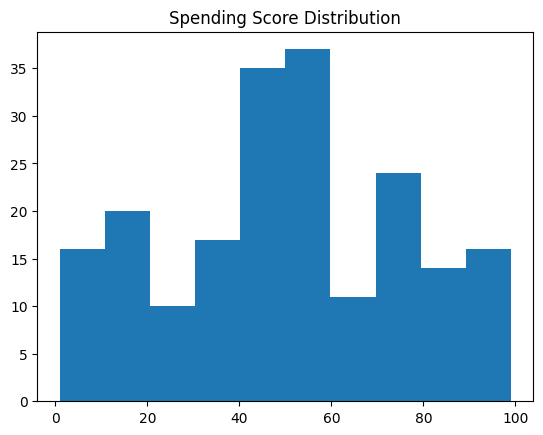

In [ ]:
# Spending Score
plt.hist(df['Spending Score (1-100)'])
plt.title("Spending Score Distribution")
plt.show()

## Bivariate Analysis (Relationship)

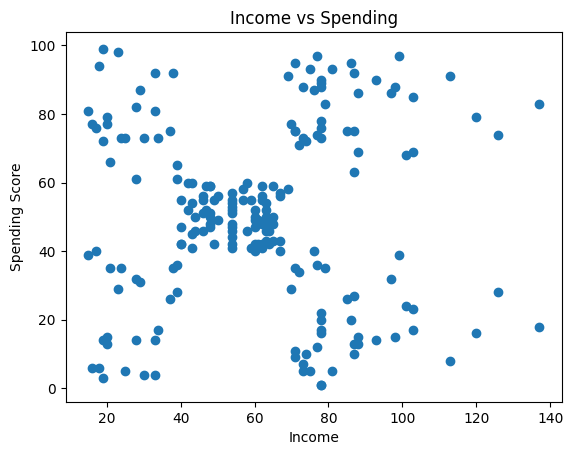

In [ ]:
#Income vs Spending Score
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending")
plt.show()

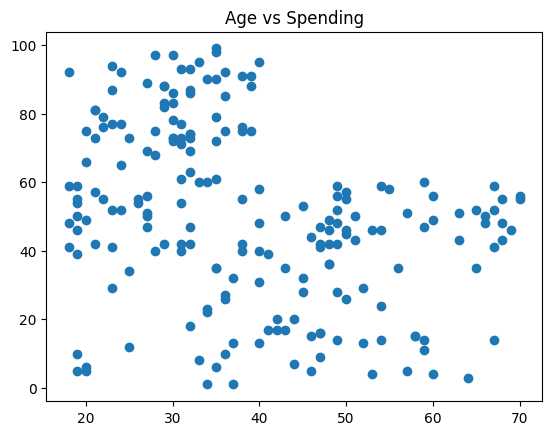

In [ ]:
# Age vs Spending
plt.scatter(df['Age'], df['Spending Score (1-100)'])
plt.title("Age vs Spending")
plt.show()

## Correlation Matrix

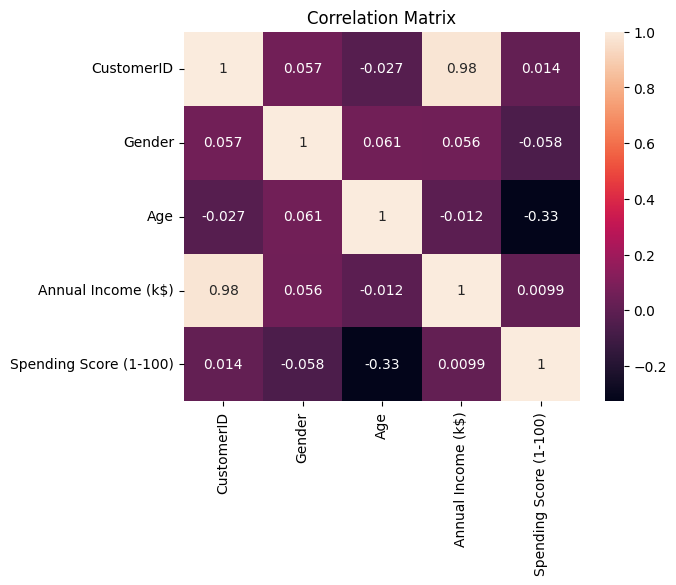

In [ ]:
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

## Outlier Detection (Boxplot)

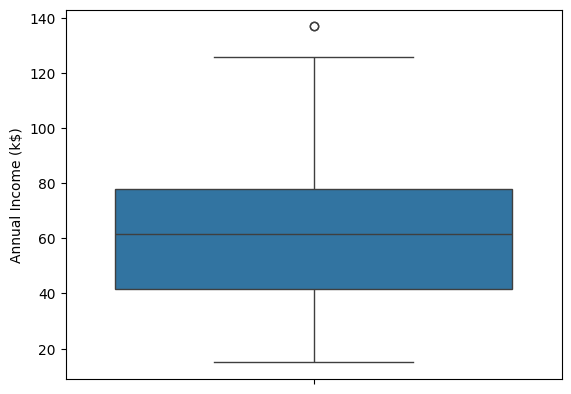

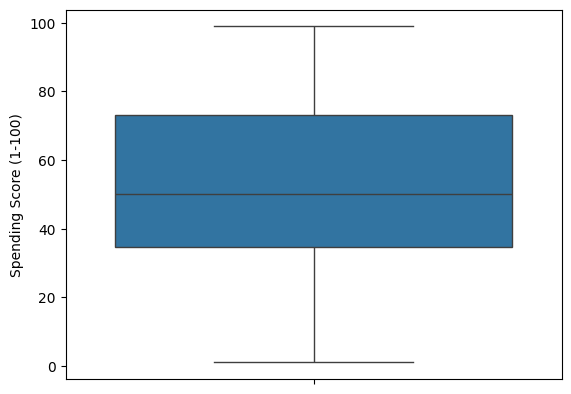

In [ ]:
sns.boxplot(df['Annual Income (k$)'])
plt.show()

sns.boxplot(df['Spending Score (1-100)'])
plt.show()

# Model Building

## Feature selection


In [ ]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

## Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Find Optimal K (Elbow Method)

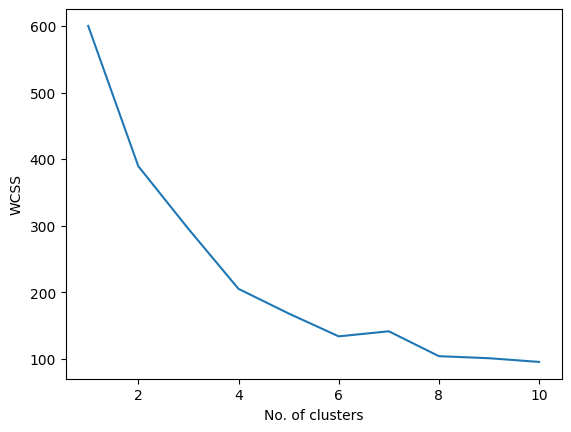

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("No. of clusters")
plt.ylabel("WCSS")
plt.show()

## Apply K-Means Model

In [ ]:
kmeans = KMeans(n_clusters=5)
df['Cluster'] = kmeans.fit_predict(X_scaled)

## Visualization

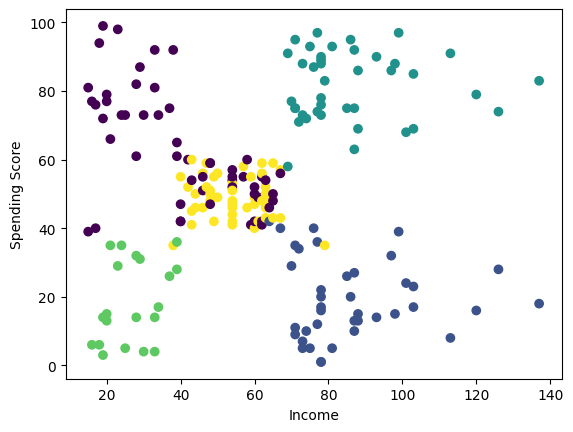

In [ ]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

**Interpretation**

Group customers into clusters

Understand behavior of each cluster

Give business insights